# Part (a): Autocorrelation

$$
w(t) = \left(1 - 2 \pi^2 f_m^2 t^2 \right) e^{- \pi^2 f_m^2 t^2 }
$$





In [16]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [17]:
fm = 40.0                # central frequency of Ricker (Hz)
Ts = 0.002               # sampling interval (s)
arrival_ms = [100, 160, 220, 280, 340, 400, 460]  # arrival times in ms
fs = 1 / Ts
f_Nyquist = fs / 2
print(f"Sampling frequency: {fs} Hz")
print(f"Nyquist frequency: {f_Nyquist} Hz")
arrival_times = [t/1000.0 for t in arrival_ms]
t_end = arrival_times[-1] + 4.0/fm + 0.05  # extra padding
N = int(np.ceil(t_end / Ts)) + 1
t_out = np.arange(0, N) * Ts
T_wavelet = 4.0 / fm           # total wavelet duration = 4 periods of fm
Lw = int(np.ceil(T_wavelet / Ts))
if Lw % 2 == 0:
    Lw += 1  # make it odd to have a true center
center_idx = Lw // 2
t_wavelet = (np.arange(Lw) - center_idx) * Ts
w = (1 - 2*(np.pi**2)*(fm**2)*(t_wavelet**2)) * np.exp(-(np.pi**2)*(fm**2)*(t_wavelet**2))
print(f"Wavelet length (samples): {Lw}")

Sampling frequency: 500.0 Hz
Nyquist frequency: 250.0 Hz
Wavelet length (samples): 51


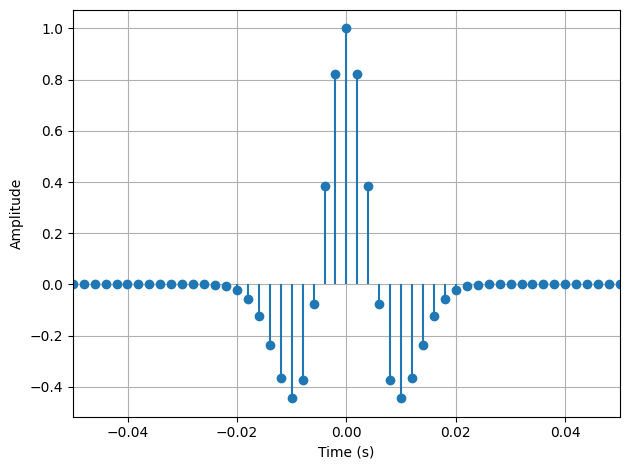

In [18]:
markerline, stemlines, baseline = plt.stem(t_wavelet, w)
baseline.set_visible(False)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.xlim(t_wavelet[0], t_wavelet[-1])
plt.tight_layout()
plt.show()


The manual autocorrelation is defined as:

$$
\text{AC}[k] = \sum_{n} x[n] \, x[n + k]
$$

For positive lags:

$$
\text{AC}[k] = \sum_{n=0}^{N-1-k} x[n] \, x[n+k], \qquad k \ge 0
$$

For negative lags:

$$
\text{AC}[k] = \sum_{n=0}^{N-1-|k|} x[n+|k|] \, x[n], \qquad k < 0
$$

Where:

- \( x[n] \) is the signal,
- \( N \) is the signal length,
- \( k \) is the lag,
- lags range from \( -(N-1) \) to \( N-1 \).


In [19]:
def manual_autocorr(x):

    x = np.asarray(x)
    N = len(x)
    maxlag = N - 1
    lags = np.arange(-maxlag, maxlag + 1)
    ac = np.zeros_like(lags, dtype=float)

    for idx, k in enumerate(lags):
        if k >= 0:
            overlap = N - k
            ac[idx] = np.sum(x[:overlap] * x[k:k+overlap])
        else:
            k2 = -k
            overlap = N - k2
            ac[idx] = np.sum(x[k2:k2+overlap] * x[:overlap])
    return lags, ac

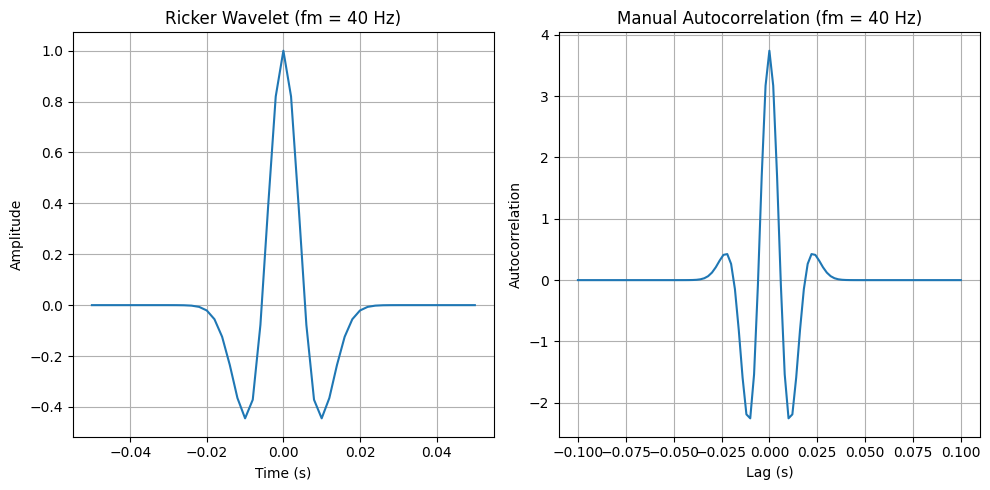

In [20]:
# Manual autocorrelation
lags_samples, ac = manual_autocorr(w)
lags_seconds = lags_samples * Ts

# Plot
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(t_wavelet, w)
plt.title("Ricker Wavelet (fm = 40 Hz)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(lags_seconds, ac)
plt.title("Manual Autocorrelation (fm = 40 Hz)")
plt.xlabel("Lag (s)")
plt.ylabel("Autocorrelation")
plt.grid(True)

plt.tight_layout()
plt.show()

In [21]:
ac

array([ 3.11308200e-31,  1.26612663e-29,  3.54834633e-28,  8.14212343e-27,
        1.61882291e-25,  2.86675878e-24,  4.59765736e-23,  6.75326716e-22,
        9.15697889e-21,  1.15247399e-19,  1.35120959e-18,  1.47907134e-17,
        1.51342313e-16,  1.44838604e-15,  1.29669958e-14,  1.08594764e-13,
        8.50598908e-13,  6.23002687e-12,  4.26567096e-11,  2.72950328e-10,
        1.63165417e-09,  9.10858569e-09,  4.74634919e-08,  2.30746464e-07,
        1.04598501e-06,  4.41814486e-06,  1.73755703e-05,  6.35656834e-05,
        2.16079644e-04,  6.81609956e-04,  1.99196189e-03,  5.38224434e-03,
        1.34106332e-02,  3.07076107e-02,  6.43158395e-02,  1.22393631e-01,
        2.09487261e-01,  3.17116186e-01,  4.11349838e-01,  4.24661629e-01,
        2.64889322e-01, -1.46835294e-01, -8.11465650e-01, -1.58913926e+00,
       -2.18872438e+00, -2.25352913e+00, -1.53623573e+00, -8.23355810e-02,
        1.70070442e+00,  3.17082813e+00,  3.74008388e+00,  3.17082813e+00,
        1.70070442e+00, -

In [22]:
lags_samples, ac = manual_autocorr(w)
lags_seconds = lags_samples * Ts

# Absolute AC
ac_abs = np.abs(ac)

# Normalized AC (R(0) = 1)
ac_norm = ac / ac[lags_samples == 0]


In [23]:
print("\n===== NUMERICAL AUTOCORRELATION RESULTS =====")
print(f"Raw AC peak (R(0)): {ac[lags_samples == 0][0]}")
print(f"Absolute AC peak: {np.max(ac_abs)}")

print("\nNormalized AC near zero-lag:")
for lag in range(-5, 6):
    idx = np.where(lags_samples == lag)[0][0]
    print(f"Lag {lag:2d} → {ac_norm[idx]: .6f}")




===== NUMERICAL AUTOCORRELATION RESULTS =====
Raw AC peak (R(0)): 3.740083878763432
Absolute AC peak: 3.740083878763432

Normalized AC near zero-lag:
Lag -5 → -0.602534
Lag -4 → -0.410749
Lag -3 → -0.022014
Lag -2 →  0.454724
Lag -1 →  0.847796
Lag  0 →  1.000000
Lag  1 →  0.847796
Lag  2 →  0.454724
Lag  3 → -0.022014
Lag  4 → -0.410749
Lag  5 → -0.602534


# Part (b): Crosscorrelation + Additive white Gaussian noise (AWGN)

In [24]:
arrival_times = [t/1000.0 for t in arrival_ms]
t_end = arrival_times[-1] + 4.0/fm + 0.05  # extra padding
N = int(np.ceil(t_end / Ts)) + 1
t_out = np.arange(0, N) * Ts

In [25]:
spike = np.zeros(N)
for t0 in arrival_times:
    idx = int(round(t0 / Ts))
    if 0 <= idx < N:
        spike[idx] += 1.0

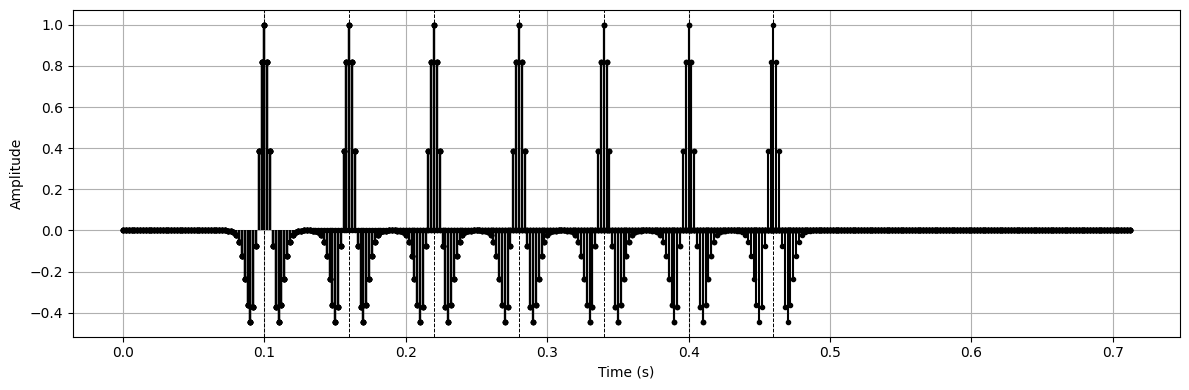

In [26]:
y_len = N + Lw - 1
y = np.zeros(y_len)
nonzero_spike_indices = np.nonzero(spike)[0]
y_steps = []
for step_idx, k in enumerate(nonzero_spike_indices, start=1):
    amp = spike[k]
    start = k - center_idx
    end = start + Lw

    y_start = max(start, 0)
    y_end = min(end, y_len)
    w_start = y_start - start
    w_end = w_start + (y_end - y_start)

    y[y_start:y_end] += amp * w[w_start:w_end]
    y_steps.append(y.copy())

t_y = np.arange(0, y_len) * Ts

plt.figure(figsize=(12, 4))

for y_step in y_steps:
    stem = plt.stem(t_y, y_step, linefmt='k-', markerfmt='ko', basefmt=' ')
    stem.markerline.set_markersize(3)
    stem.stemlines.set_color('black')
    stem.baseline.set_color('black')

for t0 in arrival_times:
    plt.axvline(t0, linestyle='--', color='black', linewidth=0.7)

plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()


## AWGN Function and Explanation

### Python Code

```python
import numpy as np

def awgn(x, snr_db):
    """
    Add AWGN to a real-valued signal for a desired SNR (in dB).
    Signal power is computed automatically.
    """
    x = np.asarray(x)
    
    # Signal power (mean of squared samples)
    ps = np.mean(x**2)
    
    # SNR: dB → linear
    snr_linear = 10**(snr_db / 10)
    
    # Noise power
    pn = ps / snr_linear
    
    # Generate white Gaussian noise
    noise = np.sqrt(pn) * np.random.randn(len(x))
    
    return x + noise


## Explanation

### 1. Signal Power

The signal power is calculated as:

$$
P_s = \frac{1}{N} \sum_{n=0}^{N-1} x[n]^2
$$


### 2. Convert SNR from dB to Linear

$$
\text{SNR}*\text{linear} = 10^{\frac{\text{SNR}*{dB}}{10}}
$$



### 3. Compute Noise Power

The noise power needed for the desired SNR is:

$$
P_n = \frac{P_s}{\text{SNR}_\text{linear}}
$$



### 4. Generate AWGN

The white Gaussian noise samples are:

$$
w[n] = \sqrt{P_n},\mathcal{N}(0,1)
$$



### 5. Add Noise to the Signal

$$
y[n] = x[n] + w[n]
$$

This produces the noisy signal with the specified SNR.



In [27]:
from awgn import awgn

In [28]:
y_snr10 = awgn(y, 10)
y_snr5  = awgn(y, 5)
y_snr03 = awgn(y, 0.3)

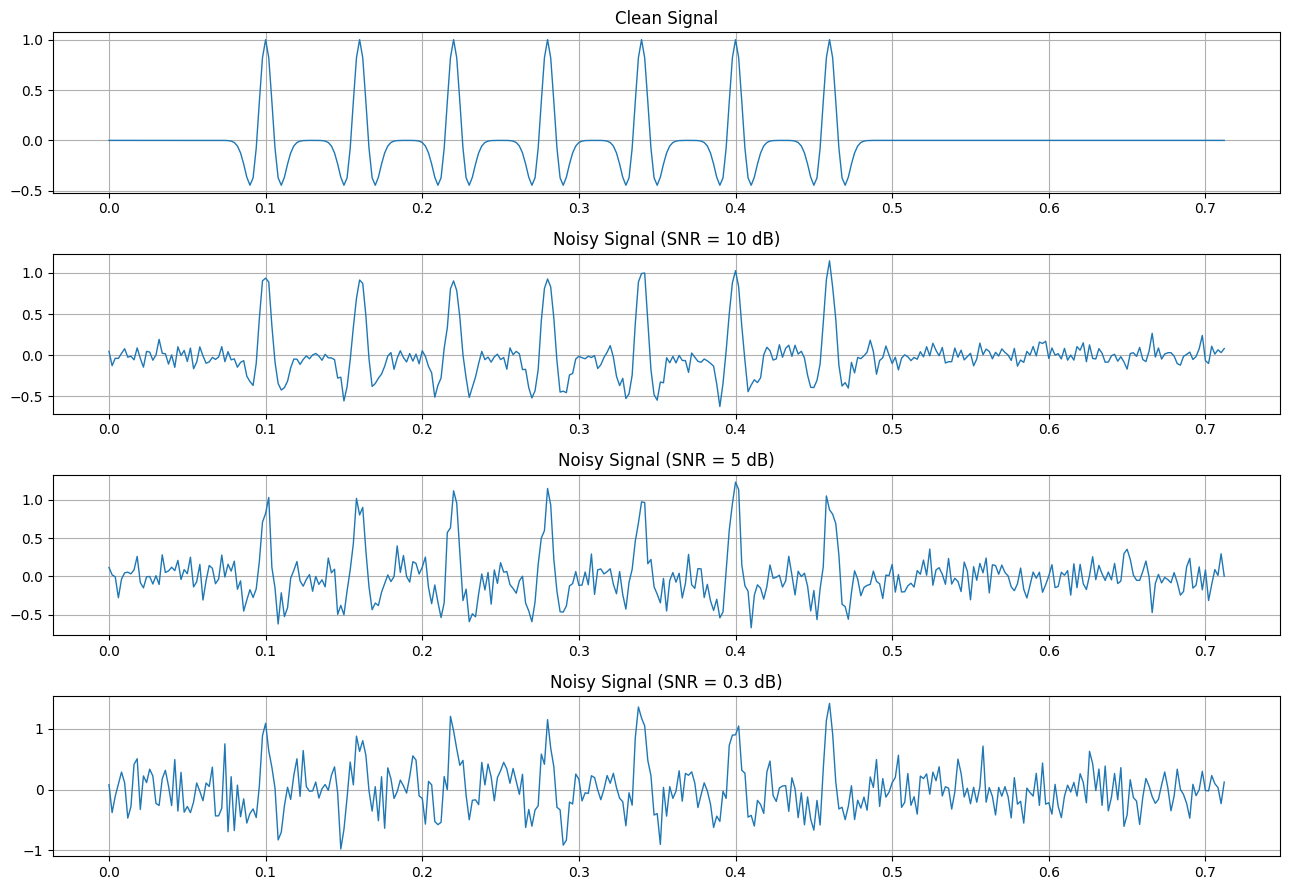

In [29]:
plt.figure(figsize=(13, 9))

plt.subplot(4,1,1)
plt.plot(t_y, y, linewidth=1)
plt.title("Clean Signal")
plt.grid(True)

plt.subplot(4,1,2)
plt.plot(t_y, y_snr10, linewidth=1)
plt.title("Noisy Signal (SNR = 10 dB)")
plt.grid(True)

plt.subplot(4,1,3)
plt.plot(t_y, y_snr5, linewidth=1)
plt.title("Noisy Signal (SNR = 5 dB)")
plt.grid(True)

plt.subplot(4,1,4)
plt.plot(t_y, y_snr03, linewidth=1)
plt.title("Noisy Signal (SNR = 0.3 dB)")
plt.grid(True)

plt.tight_layout()
plt.show()


The cross-correlation between two signals \(x[n]\) and \(y[n]\) is defined as:

$$
R_{xy}[k] = \sum_{n=-\infty}^{+\infty} x[n]\, y[n+k]
$$

For finite-length discrete signals of lengths \(N_x\) and \(N_y\), the full cross-correlation has length:

$$
N_{\text{out}} = N_x + N_y - 1
$$

In the implementation, the operation is done by time-reversing \(y[n]\):

$$
y_{\text{flip}}[n] = y[N_y - 1 - n]
$$
Then for each output index \(m\):

$$
\text{corr}[m] = \sum_{k=0}^{N_x-1}
    x[k] \, y_{\text{flip}}[m - k]
$$

with valid terms only when:

$$
0 \le m - k < N_y
$$

This is equivalent to full-mode cross-correlation without using
\(\text{numpy.correlate}\).


In [30]:
def manual_xcorr(x, y):

    x = np.asarray(x)
    y = np.asarray(y)

    Nx = len(x)
    Ny = len(y)
    out_len = Nx + Ny - 1
    
    corr = np.zeros(out_len)

    # Flip y for cross-correlation
    y_flip = y[::-1]

    # Compute correlation
    for n in range(out_len):
        total = 0.0
        for k in range(Nx):
            j = n - k
            if 0 <= j < Ny:
                total += x[k] * y_flip[j]
        corr[n] = total

    return corr

In [31]:
corr_clean = manual_xcorr(y, w)
corr_snr10 = manual_xcorr(y_snr10, w)
corr_snr5  = manual_xcorr(y_snr5, w)
corr_snr03 = manual_xcorr(y_snr03, w)

In [32]:
t_corr = np.arange(len(corr_clean)) * Ts

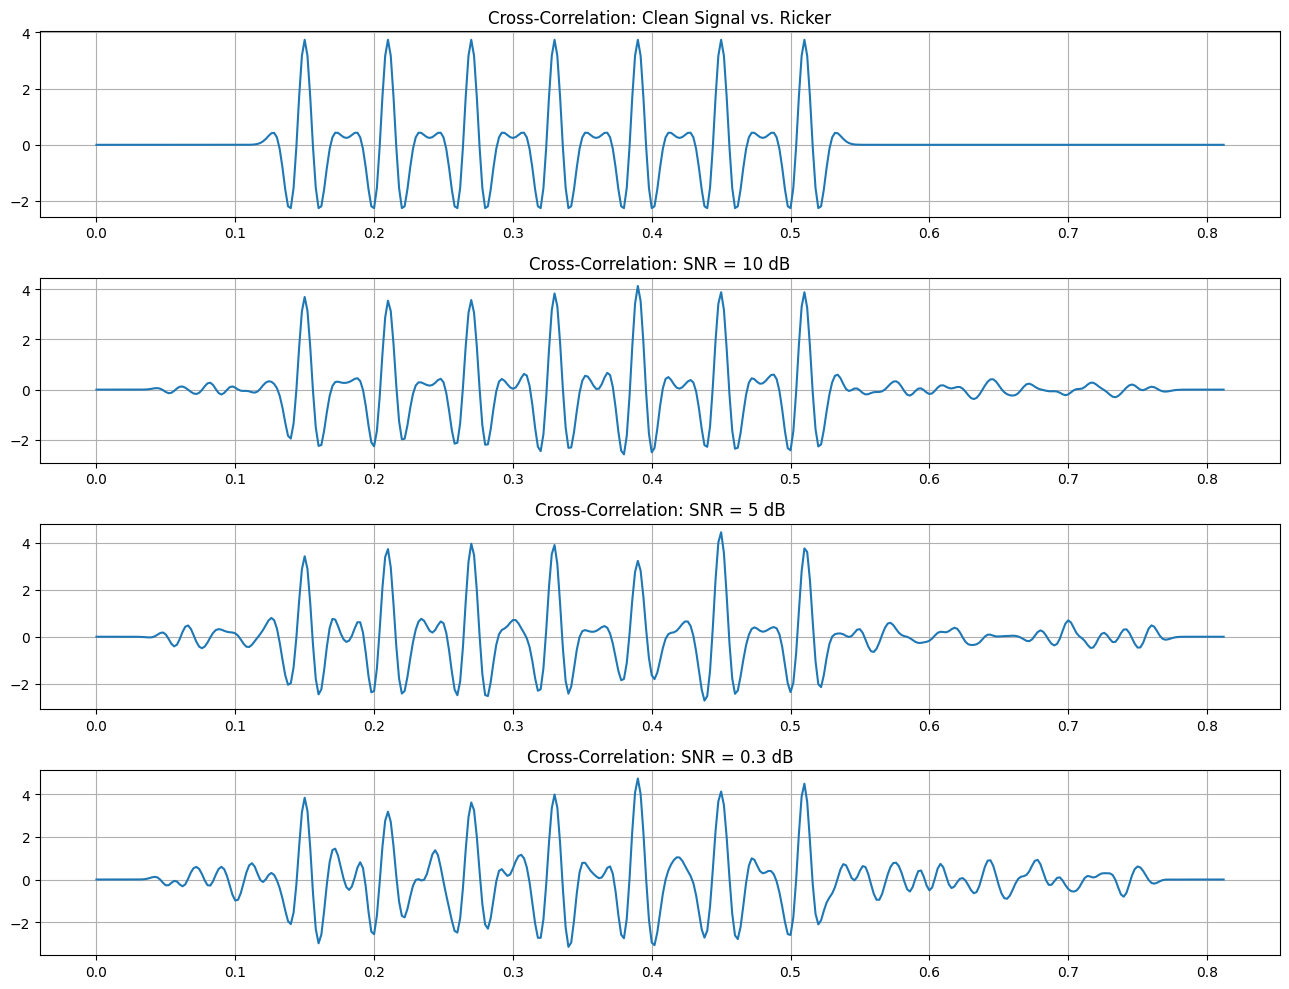

In [33]:
plt.figure(figsize=(13, 10))

plt.subplot(4,1,1)
plt.plot(t_corr, corr_clean)
plt.title("Cross-Correlation: Clean Signal vs. Ricker")
plt.grid(True)

plt.subplot(4,1,2)
plt.plot(t_corr, corr_snr10)
plt.title("Cross-Correlation: SNR = 10 dB")
plt.grid(True)

plt.subplot(4,1,3)
plt.plot(t_corr, corr_snr5)
plt.title("Cross-Correlation: SNR = 5 dB")
plt.grid(True)

plt.subplot(4,1,4)
plt.plot(t_corr, corr_snr03)
plt.title("Cross-Correlation: SNR = 0.3 dB")
plt.grid(True)

plt.tight_layout()
plt.show()


In [34]:
corr_clean_abs = np.abs(corr_clean)
corr_snr10_abs = np.abs(corr_snr10)
corr_snr5_abs  = np.abs(corr_snr5)
corr_snr03_abs = np.abs(corr_snr03)

In [35]:
corr_clean_norm = corr_clean / np.max(corr_clean_abs)
corr_snr10_norm = corr_snr10 / np.max(corr_snr10_abs)
corr_snr5_norm  = corr_snr5  / np.max(corr_snr5_abs)
corr_snr03_norm = corr_snr03 / np.max(corr_snr03_abs)

In [36]:
def print_results(name, corr, corr_abs, corr_norm):
    pk = np.argmax(corr_abs)
    print(f"\n===== {name} =====")
    print(f"Raw peak value: {corr[pk]:.6f}")
    print(f"Abs peak value: {corr_abs[pk]:.6f}")
    print(f"Peak index:     {pk}")
    print(f"Normalized peak: {corr_norm[pk]:.6f}")  # must be 1.0


print_results("CLEAN",  corr_clean,  corr_clean_abs,  corr_clean_norm)
print_results("SNR 10", corr_snr10,  corr_snr10_abs,  corr_snr10_norm)
print_results("SNR 5",  corr_snr5,   corr_snr5_abs,   corr_snr5_norm)
print_results("SNR 0.3",corr_snr03,  corr_snr03_abs,   corr_snr03_norm)


===== CLEAN =====
Raw peak value: 3.740084
Abs peak value: 3.740084
Peak index:     105
Normalized peak: 1.000000

===== SNR 10 =====
Raw peak value: 4.131403
Abs peak value: 4.131403
Peak index:     195
Normalized peak: 1.000000

===== SNR 5 =====
Raw peak value: 4.438480
Abs peak value: 4.438480
Peak index:     225
Normalized peak: 1.000000

===== SNR 0.3 =====
Raw peak value: 4.732637
Abs peak value: 4.732637
Peak index:     195
Normalized peak: 1.000000


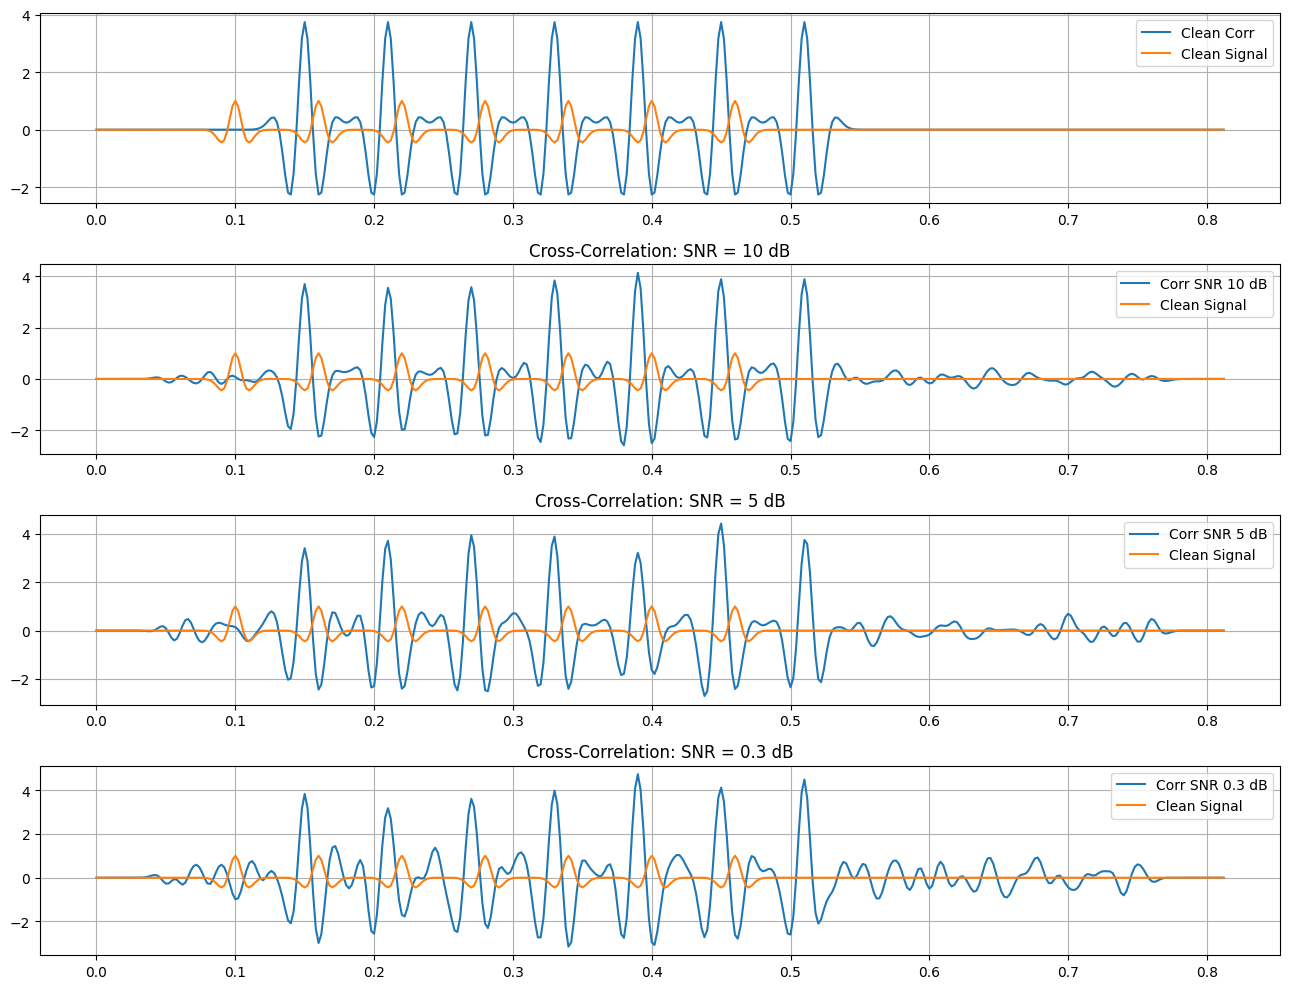

In [43]:
y_resampled = np.interp(t_corr, t_y, y)

plt.figure(figsize=(13, 10))

# --- 1 ---
plt.subplot(4,1,1)
plt.plot(t_corr, corr_clean, label="Clean Corr")
plt.plot(t_corr, y_resampled, label="Clean Signal")
plt.grid(True)
plt.legend()

# --- 2 ---
plt.subplot(4,1,2)
plt.plot(t_corr, corr_snr10, label="Corr SNR 10 dB")
plt.plot(t_corr, y_resampled, label="Clean Signal")
plt.title("Cross-Correlation: SNR = 10 dB")
plt.grid(True)
plt.legend()

# --- 3 ---
plt.subplot(4,1,3)
plt.plot(t_corr, corr_snr5, label="Corr SNR 5 dB")
plt.plot(t_corr, y_resampled, label="Clean Signal")
plt.title("Cross-Correlation: SNR = 5 dB")
plt.grid(True)
plt.legend()

# --- 4 ---
plt.subplot(4,1,4)
plt.plot(t_corr, corr_snr03, label="Corr SNR 0.3 dB")
plt.plot(t_corr, y_resampled, label="Clean Signal")
plt.title("Cross-Correlation: SNR = 0.3 dB")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()
